In [2]:
# Table 1 
import pandas as pd
from great_tables import GT, style, loc, md
import os

event_meta = pd.read_csv("../data/event_meta_data.csv")
event_meta["date"] = pd.to_datetime(event_meta["date"])
fan_votes = pd.read_csv("../data/fan_votes.csv")
chat = pd.read_csv("../data/yt_live_chat_sentiment.csv")

match_votes = (
    fan_votes
    .groupby(["event_name", "round", "match"], as_index=False)
    .agg(total_fan_vote_counts=("total_fan_vote", "first"))
)

match_chat = (
    chat
    .groupby(["event_name", "round", "match"], as_index=False)
    .agg(total_unique_livechat_commentors=("author_name", "nunique"))
)

df = match_votes.merge(match_chat, on=["event_name", "round", "match"], how="left")
df = df.merge(event_meta, on="event_name", how="left")

df["est_online_voters"] = df["total_fan_vote_counts"] - df["capacity"]
df["est_pct_online_voters"] = (
    df["est_online_voters"] / df["total_fan_vote_counts"] * 100
)

df = df.rename(
    columns={
        "event_name": "event",
        "round": "r",
        "match": "m",
        "venue": "venue",
        "capacity": "max_venue_capacity",
    }
)

df = df[
    [
        "event",
        "date",
        "r",
        "m",
        "venue",
        "max_venue_capacity",
        "total_fan_vote_counts",
        "est_online_voters",
        "est_pct_online_voters",
        "total_unique_livechat_commentors",
    ]
].sort_values(["date", "r", "m"]).reset_index(drop=True)

max_row_idx_per_event = df.groupby("event")["total_fan_vote_counts"].idxmax()
highlight_rows = df.index[df.index.isin(max_row_idx_per_event)].tolist()

gt_tbl = (
    GT(df)
    .tab_header(
        title="Table 1: Venue Capacity, Fan Vote, and Live Chat Commenter Counts by IDL Match",
    )
    .cols_label(
        event="Event",
        date="Date",
        r="Round",
        m="Match",
        venue="Venue",
        max_venue_capacity="Max Venue Capacity",
        total_fan_vote_counts="Total Fan Votes",
        est_online_voters="Est. Online Votes",
        est_pct_online_voters="Est. % Online Votes",
        total_unique_livechat_commentors="Unique Live Chat Commenters",
    )
    .fmt_date(columns=["date"], date_style="iso")
    .fmt_number(
        columns=["max_venue_capacity", "total_fan_vote_counts", "est_online_voters"],
        decimals=0,
        sep_mark=",",
    )
    .fmt_percent(columns=["est_pct_online_voters"], scale_values=False, decimals=0)
    .fmt_integer(columns=["total_unique_livechat_commentors"])
    .sub_missing(
        columns=["total_unique_livechat_commentors"],
        missing_text="N/A",
    )
    .tab_style(
        style=style.fill(color="#E0E0E0"),
        locations=loc.body(rows=highlight_rows),
    )
    .tab_source_note(
        source_note=md(
            "Est. online voters = total fan vote count − max venue capacity.<br>"
            "Highlighted rows mark each event's highest-vote match.<br>"
            "N/A indicates live chat replay was not enabled for those event livestreams."
        )
    )
    .tab_options(
        container_padding_y="12px",
        heading_padding="20px",
        source_notes_padding="16px",
    )
    .tab_style(
        style=[style.text(transform="uppercase", align="left")],
        locations=loc.column_labels(),
    )
)

output_dir = "../results/tables_and_figures"
os.makedirs(output_dir, exist_ok=True)
gt_tbl.gtsave(f"{output_dir}/table1_event_summary.png", zoom=2, vwidth=1600, vheight=900)

GT(_tbl_data=        event       date  r  m                            venue  \
0    New York 2026-05-02  1  1             Hammerstein Ballroom   
1    New York 2026-05-02  1  2             Hammerstein Ballroom   
2    New York 2026-05-02  1  3             Hammerstein Ballroom   
3    New York 2026-05-02  2  1             Hammerstein Ballroom   
4   Vancouver 2026-05-23  1  1        Thunderbird Sports Centre   
5   Vancouver 2026-05-23  1  2        Thunderbird Sports Centre   
6   Vancouver 2026-05-23  1  3        Thunderbird Sports Centre   
7   Vancouver 2026-05-23  2  1        Thunderbird Sports Centre   
8      Sydney 2026-06-20  1  1            The Hordern Pavillion   
9      Sydney 2026-06-20  1  2            The Hordern Pavillion   
10     Sydney 2026-06-20  1  3            The Hordern Pavillion   
11     Sydney 2026-06-20  2  1            The Hordern Pavillion   
12      Seoul 2026-08-01  1  1  Kyung Hee University Peace Hall   
13      Seoul 2026-08-01  1  2  Kyung Hee University Peace Hall   
14      Seoul 2026-08-01  1  3  Kyung Hee University Peace Hall   
15      Seoul 2026-08-01  2  1  Kyung Hee University Peace Hall   

    max_venue_capacity  total_fan_vote_counts  est_online_voters  \
0                 3500                   1649              -1851   
1                 3500                   2924               -576   
2                 3500                   3008               -492   
3                 3500                   1950              -1550   
4                 7000                   7779                779   
5                 7000                   8733               1733   
6                 7000                   9671               2671   
7                 7000                   8303               1303   
8                 5500                   9175               3675   
9                 5500                   8975               3475   
10                5500                  10521               5021   
11                5500                   9153               3653   
12                4500                   9504               5004   
13                4500                  10826               6326   
14                4500                  10707               6207   
15                4500                  13343               8843   

    est_pct_online_voters  total_unique_livechat_commentors  
0             -112.249848                               NaN  
1              -19.699042                               NaN  
2              -16.356383                               NaN  
3              -79.487179                               NaN  
4               10.014141                               NaN  
5               19.844269                               NaN  
6               27.618654                               NaN  
7               15.693123                               NaN  
8               40.054496                               7.0  
9               38.718663                               3.0  
10              47.723600                               8.0  
11              39.910412                               2.0  
12              52.651515                             266.0  
13              58.433401                             354.0  
14              57.971421                             346.0  
15              66.274451                             469.0  , _body=<great_tables._gt_data.Body object at 0x000001AD3AFAD490>, _boxhead=Boxhead([ColInfo(var='event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width=None), ColInfo(var='date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Round', column_align='right', column_width=None), ColInfo(var='m', type=<ColInfoTypeEnum.default: 1>, column_label='Match', column_align='right', column_width=None), ColInfo(var='venue', type=<ColInfoTypeEnum.default: 1>, column_label='Venue', colum

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
from great_tables import GT, style, loc, md
import os

EVENTS = ["Seoul", "Sydney"]

fan_votes = pd.read_csv("../data/fan_votes.csv")
chat = pd.read_csv("../data/yt_live_chat_sentiment.csv")

fan_votes = fan_votes[fan_votes["event_name"].isin(EVENTS)]
chat = chat[chat["event_name"].isin(EVENTS)]

fan_votes["fan_vote_share"] = fan_votes["fan_vote_pct"] / 100

fan_votes = fan_votes[
    ["event_name", "round", "match", "team", "fan_vote_count", "fan_vote_share"]
]

sentiment = (
    chat
    .groupby(["event_name", "round", "match", "team", "sentiment"])
    .size()
    .unstack(fill_value=0)
)
sentiment["total_comments"] = sentiment.sum(axis=1)
sentiment["net_sentiment"] = (
    sentiment.get("Positive", 0) - sentiment.get("Negative", 0)
) / sentiment["total_comments"]
sentiment = sentiment.reset_index()[
    ["event_name", "round", "match", "team", "total_comments", "net_sentiment"]
]

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

sentiment["sentiment_share"] = sentiment.groupby(
    ["event_name", "round", "match"]
)["net_sentiment"].transform(softmax)

combined = fan_votes.merge(
    sentiment, on=["event_name", "round", "match", "team"], how="inner"
)

def tau_ci(tau, n, ci=0.95):
    from scipy.stats import norm
    z = np.arctanh(tau)
    se = 1 / np.sqrt(n - 3)
    z_crit = norm.ppf(1 - (1 - ci) / 2)
    lo = np.tanh(z - z_crit * se)
    hi = np.tanh(z + z_crit * se)
    return lo, hi

results = []
for r in sorted(combined["round"].unique()):
    subset = combined[combined["round"] == r]
    n = len(subset)
    tau, p_value = kendalltau(subset["fan_vote_share"], subset["sentiment_share"])
    ci_lo, ci_hi = tau_ci(tau, n)
    results.append({
        "round": r,
        "n": n,
        "tau": tau,
        "p_value": p_value,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
    })

kendall_results = pd.DataFrame(results)

fan_vote_tbl = (
    GT(fan_votes.rename(columns={
        "event_name": "event",
        "round": "r",
        "match": "m",
    }))
    .tab_header(title="Table 2: Fan Vote Share by Team, Seoul and Sydney Events")
    .cols_label(
        event="Event",
        r="Round",
        m="Match",
        team="Team",
        fan_vote_count="Fan Votes",
        fan_vote_share="Fan Vote Share",
    )
    .fmt_number(columns=["fan_vote_count"], decimals=0, sep_mark=",")
    .fmt_percent(columns=["fan_vote_share"], decimals=1)
    .tab_options(
        container_padding_y="12px",
        heading_padding="20px",
        source_notes_padding="16px",
    )
    .tab_style(
        style=[style.text(transform="uppercase", align="left")],
        locations=loc.column_labels(),
    )
)

sentiment_tbl = (
    GT(sentiment.rename(columns={
        "event_name": "event",
        "round": "r",
        "match": "m",
    }))
    .tab_header(title="Table 3: Live Chat Net Sentiment by Team, Seoul and Sydney Events")
    .cols_label(
        event="Event",
        r="Round",
        m="Match",
        team="Team",
        total_comments="Comments",
        net_sentiment="Net Sentiment",
        sentiment_share="Sentiment Share",
    )
    .fmt_integer(columns=["total_comments"])
    .fmt_number(columns=["net_sentiment"], decimals=3)
    .fmt_percent(columns=["sentiment_share"], decimals=1)
    .tab_source_note(
        source_note=md(
            "Sentiment share is a softmax normalization of net sentiment within each match."
        )
    )
    .tab_options(
        container_padding_y="12px",
        heading_padding="20px",
        source_notes_padding="16px",
    )
    .tab_style(
        style=[style.text(transform="uppercase", align="left")],
        locations=loc.column_labels(),
    )
)

kendall_tbl = (
    GT(kendall_results.rename(columns={"round": "r"}))
    .tab_header(title="Table 4: Kendall's Tau Between Fan Vote Share and Sentiment Share")
    .cols_label(
        r="Round",
        n="N",
        tau="Kendall's Tau",
        p_value="P-Value",
        ci_lo="95% CI Lower",
        ci_hi="95% CI Upper",
    )
    .fmt_number(columns=["tau", "p_value", "ci_lo", "ci_hi"], decimals=3)
    .tab_source_note(
        source_note=md(
            "95% confidence intervals computed via Fisher z-transformation of Kendall's tau."
        )
    )
    .tab_options(
        container_padding_y="12px",
        heading_padding="20px",
        source_notes_padding="16px",
    )
    .tab_style(
        style=[style.text(transform="uppercase", align="left")],
        locations=loc.column_labels(),
    )
)

output_dir = "../results/tables_and_figures"
os.makedirs(output_dir, exist_ok=True)
fan_vote_tbl.gtsave(f"{output_dir}/table2_fan_vote_share.png", zoom=2, vwidth=1400, vheight=800)
sentiment_tbl.gtsave(f"{output_dir}/table3_sentiment_share.png", zoom=2, vwidth=1400, vheight=800)
kendall_tbl.gtsave(f"{output_dir}/table4_kendall_tau.png", zoom=2, vwidth=1400, vheight=800)

print(kendall_results)

   round   n       tau   p_value     ci_lo     ci_hi
0      1  12  0.303030  0.196950 -0.327895  0.747018
1      2   5 -0.105409  0.800542 -0.903638  0.856512


In [7]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau, norm
from great_tables import GT, style, loc, md
import os

EVENTS = ["Seoul", "Sydney"]

fan_votes = pd.read_csv("../data/fan_votes.csv")
judges = pd.read_csv("../data/judges_match_averages.csv")

fan_votes = fan_votes[fan_votes["event_name"].isin(EVENTS)]
judges = judges[judges["event_name"].isin(EVENTS)]

fan_votes["fan_vote_share"] = fan_votes["fan_vote_pct"] / 100

fan_votes = fan_votes[
    ["event_name", "round", "match", "team", "fan_vote_count", "fan_vote_share"]
]

judges_match = (
    judges
    .groupby(["event_name", "round", "match", "team"], as_index=False)
    .agg(judges_match_averages=("judges_match_averages", "first"))
)

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

judges_match["judges_share"] = judges_match.groupby(
    ["event_name", "round", "match"]
)["judges_match_averages"].transform(softmax)

combined = fan_votes.merge(
    judges_match, on=["event_name", "round", "match", "team"], how="inner"
)

def tau_ci(tau, n, ci=0.95):
    z = np.arctanh(tau)
    se = 1 / np.sqrt(n - 3)
    z_crit = norm.ppf(1 - (1 - ci) / 2)
    lo = np.tanh(z - z_crit * se)
    hi = np.tanh(z + z_crit * se)
    return lo, hi

results = []
for r in sorted(combined["round"].unique()):
    subset = combined[combined["round"] == r]
    n = len(subset)
    tau, p_value = kendalltau(subset["fan_vote_share"], subset["judges_share"])
    ci_lo, ci_hi = tau_ci(tau, n)
    results.append({
        "round": r,
        "n": n,
        "tau": tau,
        "p_value": p_value,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
    })

kendall_results = pd.DataFrame(results)

judges_tbl = (
    GT(judges_match.rename(columns={
        "event_name": "event",
        "round": "r",
        "match": "m",
    }))
    .tab_header(title="Table 5: Judges Match Average Score by Team, Seoul and Sydney Events")
    .cols_label(
        event="Event",
        r="Round",
        m="Match",
        team="Team",
        judges_match_averages="Judges Match Average",
        judges_share="Judges Share",
    )
    .fmt_number(columns=["judges_match_averages"], decimals=2)
    .fmt_percent(columns=["judges_share"], decimals=1)
    .tab_source_note(
        source_note=md(
            "Judges share is a softmax normalization of judges match average score within each match."
        )
    )
    .tab_options(
        container_padding_y="12px",
        heading_padding="20px",
        source_notes_padding="16px",
    )
    .tab_style(
        style=[style.text(transform="uppercase", align="left")],
        locations=loc.column_labels(),
    )
)

kendall_tbl = (
    GT(kendall_results.rename(columns={"round": "r"}))
    .tab_header(title="Table 6: Kendall's Tau Between Fan Vote Share and Judges Share")
    .cols_label(
        r="Round",
        n="N",
        tau="Kendall's Tau",
        p_value="P-Value",
        ci_lo="95% CI Lower",
        ci_hi="95% CI Upper",
    )
    .fmt_number(columns=["tau", "p_value", "ci_lo", "ci_hi"], decimals=3)
    .tab_source_note(
        source_note=md(
            "95% confidence intervals computed via Fisher z-transformation of Kendall's tau."
        )
    )
    .tab_options(
        container_padding_y="12px",
        heading_padding="20px",
        source_notes_padding="16px",
    )
    .tab_style(
        style=[style.text(transform="uppercase", align="left")],
        locations=loc.column_labels(),
    )
)

output_dir = "../results/tables_and_figures"
os.makedirs(output_dir, exist_ok=True)
judges_tbl.gtsave(f"{output_dir}/table5_judges_share.png", zoom=2, vwidth=1400, vheight=800)
kendall_tbl.gtsave(f"{output_dir}/table6_kendall_tau_judges.png", zoom=2, vwidth=1400, vheight=800)

print(kendall_results)

   round   n       tau   p_value     ci_lo     ci_hi
0      1  12  0.923186  0.000036  0.742871  0.978605
1      2   6  0.600000  0.136111 -0.412349  0.949308


    round                            category   n       tau   p_value
0       1             Choreography Complexity  12  0.381385  0.093959
1       1                         Cleanliness  12  0.757576  0.000240
2       1                          Creativity  12  0.646230  0.003807
3       1                          Musicality  12  0.190693  0.400814
4       1            Projection/Communication  12  0.757576  0.000240
5       1                             Spacing  12  0.299445  0.187346
6       1                             Staging  12  0.492366  0.027474
7       1                             Stamina  12  0.606061  0.005380
8       1               Stylistic Athleticism  12  0.553912  0.013127
9       1  Technical Execution + Authenticity  12  0.606061  0.005380
10      2             Choreography Complexity   6  0.333333  0.469444
11      2                         Cleanliness   6  0.466667  0.272222
12      2                          Creativity   6  1.000000  0.002778
13      2           

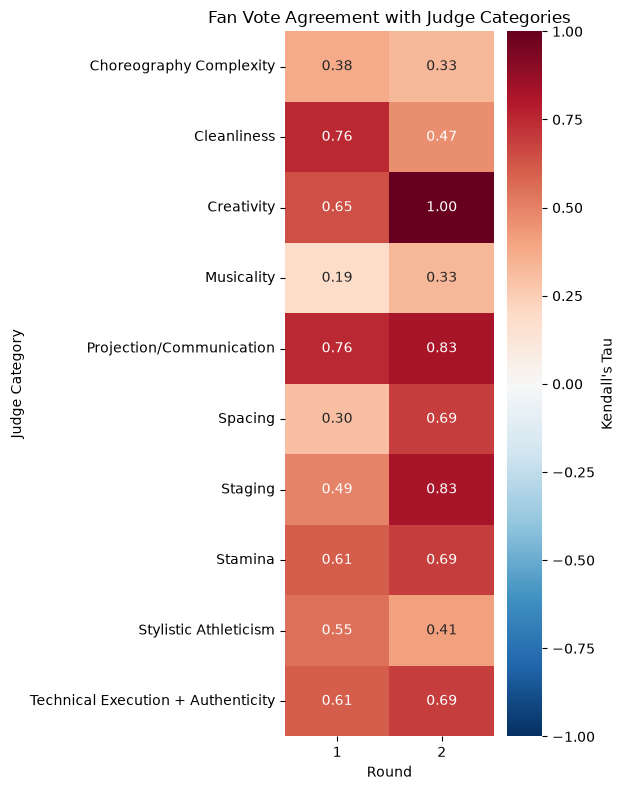

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
import os

EVENTS = ["Seoul", "Sydney"]

fan_votes = pd.read_csv("../data/fan_votes.csv")
judges = pd.read_csv("../data/judges_match_averages.csv")

fan_votes = fan_votes[fan_votes["event_name"].isin(EVENTS)]
judges = judges[judges["event_name"].isin(EVENTS)]

fan_votes["fan_vote_share"] = fan_votes["fan_vote_pct"] / 100
fan_votes = fan_votes[["event_name", "round", "match", "team", "fan_vote_share"]]

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

judges["category_share"] = judges.groupby(
    ["event_name", "round", "match", "category"]
)["judges_category_averages"].transform(softmax)

combined = judges.merge(
    fan_votes, on=["event_name", "round", "match", "team"], how="inner"
)

results = []
for (r, cat), group in combined.groupby(["round", "category"]):
    n = len(group)
    if n < 4:
        tau, p_value = np.nan, np.nan
    else:
        tau, p_value = kendalltau(group["fan_vote_share"], group["category_share"])
    results.append({"round": r, "category": cat, "n": n, "tau": tau, "p_value": p_value})

tau_df = pd.DataFrame(results)

heatmap_data = tau_df.pivot(index="category", columns="round", values="tau")

fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Kendall's Tau"},
    ax=ax,
)
ax.set_title("Fan Vote Agreement with Judge Categories")
ax.set_xlabel("Round")
ax.set_ylabel("Judge Category")
plt.tight_layout()

output_dir = "../results/tables_and_figures"
os.makedirs(output_dir, exist_ok=True)
fig.savefig(f"{output_dir}/fig1_category_tau_heatmap.png", dpi=300)

tau_df.to_csv(f"{output_dir}/category_tau_results.csv", index=False)

print(tau_df)

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau, norm
from great_tables import GT, style, loc, md
import os

EVENTS = ["Seoul", "Sydney"]

judges = pd.read_csv("../data/judges_match_averages.csv")
chat = pd.read_csv("../data/yt_live_chat_sentiment.csv")

judges = judges[judges["event_name"].isin(EVENTS)]
chat = chat[chat["event_name"].isin(EVENTS)]

judges_match = (
    judges
    .groupby(["event_name", "round", "match", "team"], as_index=False)
    .agg(judges_match_averages=("judges_match_averages", "first"))
)

sentiment = (
    chat
    .groupby(["event_name", "round", "match", "team", "sentiment"])
    .size()
    .unstack(fill_value=0)
)
sentiment["total_comments"] = sentiment.sum(axis=1)
sentiment["net_sentiment"] = (
    sentiment.get("Positive", 0) - sentiment.get("Negative", 0)
) / sentiment["total_comments"]
sentiment = sentiment.reset_index()[
    ["event_name", "round", "match", "team", "total_comments", "net_sentiment"]
]

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

judges_match["judges_share"] = judges_match.groupby(
    ["event_name", "round", "match"]
)["judges_match_averages"].transform(softmax)

sentiment["sentiment_share"] = sentiment.groupby(
    ["event_name", "round", "match"]
)["net_sentiment"].transform(softmax)

combined = judges_match.merge(
    sentiment, on=["event_name", "round", "match", "team"], how="inner"
)

def tau_ci(tau, n, ci=0.95):
    z = np.arctanh(tau)
    se = 1 / np.sqrt(n - 3)
    z_crit = norm.ppf(1 - (1 - ci) / 2)
    lo = np.tanh(z - z_crit * se)
    hi = np.tanh(z + z_crit * se)
    return lo, hi

results = []
for r in sorted(combined["round"].unique()):
    subset = combined[combined["round"] == r]
    n = len(subset)
    tau, p_value = kendalltau(subset["judges_share"], subset["sentiment_share"])
    ci_lo, ci_hi = tau_ci(tau, n)
    results.append({
        "round": r,
        "n": n,
        "tau": tau,
        "p_value": p_value,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
    })

kendall_results = pd.DataFrame(results)

kendall_tbl = (
    GT(kendall_results.rename(columns={"round": "r"}))
    .tab_header(title="Table 7: Kendall's Tau Between Judges Share and Sentiment Share")
    .cols_label(
        r="Round",
        n="N",
        tau="Kendall's Tau",
        p_value="P-Value",
        ci_lo="95% CI Lower",
        ci_hi="95% CI Upper",
    )
    .fmt_number(columns=["tau", "p_value", "ci_lo", "ci_hi"], decimals=3)
    .tab_source_note(
        source_note=md(
            "95% confidence intervals computed via Fisher z-transformation of Kendall's tau."
        )
    )
    .tab_options(
        container_padding_y="12px",
        heading_padding="20px",
        source_notes_padding="16px",
    )
    .tab_style(
        style=[style.text(transform="uppercase", align="left")],
        locations=loc.column_labels(),
    )
)

output_dir = "../results/tables_and_figures"
os.makedirs(output_dir, exist_ok=True)
kendall_tbl.gtsave(f"{output_dir}/table7_kendall_tau_judges_sentiment.png", zoom=2, vwidth=1400, vheight=800)

print(kendall_results)

   round   n       tau   p_value     ci_lo     ci_hi
0      1  12  0.215410  0.334764 -0.409061  0.702469
1      2   5  0.105409  0.800542 -0.856512  0.903638


    round                            category   n       tau   p_value
0       1             Choreography Complexity  12 -0.222475  0.328565
1       1                         Cleanliness  12  0.424242  0.062869
2       1                          Creativity  12  0.123091  0.581511
3       1                          Musicality  12 -0.476731  0.035692
4       1            Projection/Communication  12  0.424242  0.062869
5       1                             Spacing  12  0.709211  0.001792
6       1                             Staging  12  0.092319  0.679326
7       1                             Stamina  12  0.333333  0.152590
8       1               Stylistic Athleticism  12  0.215410  0.334764
9       1  Technical Execution + Authenticity  12 -0.090909  0.737306
10      2             Choreography Complexity   5 -0.105409  0.800542
11      2                         Cleanliness   5  0.105409  0.800542
12      2                          Creativity   5 -0.105409  0.800542
13      2           

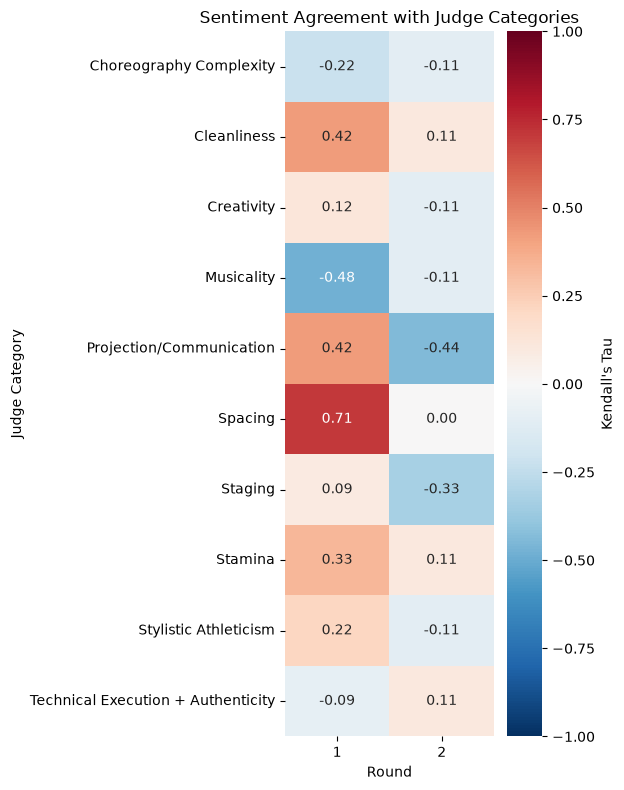

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
import os

EVENTS = ["Seoul", "Sydney"]

judges = pd.read_csv("../data/judges_match_averages.csv")
chat = pd.read_csv("../data/yt_live_chat_sentiment.csv")

judges = judges[judges["event_name"].isin(EVENTS)]
chat = chat[chat["event_name"].isin(EVENTS)]

sentiment = (
    chat
    .groupby(["event_name", "round", "match", "team", "sentiment"])
    .size()
    .unstack(fill_value=0)
)
sentiment["total_comments"] = sentiment.sum(axis=1)
sentiment["net_sentiment"] = (
    sentiment.get("Positive", 0) - sentiment.get("Negative", 0)
) / sentiment["total_comments"]
sentiment = sentiment.reset_index()[
    ["event_name", "round", "match", "team", "net_sentiment"]
]

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

sentiment["sentiment_share"] = sentiment.groupby(
    ["event_name", "round", "match"]
)["net_sentiment"].transform(softmax)

judges["category_share"] = judges.groupby(
    ["event_name", "round", "match", "category"]
)["judges_category_averages"].transform(softmax)

combined = judges.merge(
    sentiment, on=["event_name", "round", "match", "team"], how="inner"
)

results = []
for (r, cat), group in combined.groupby(["round", "category"]):
    n = len(group)
    if n < 4:
        tau, p_value = np.nan, np.nan
    else:
        tau, p_value = kendalltau(group["sentiment_share"], group["category_share"])
    results.append({"round": r, "category": cat, "n": n, "tau": tau, "p_value": p_value})

tau_df = pd.DataFrame(results)

heatmap_data = tau_df.pivot(index="category", columns="round", values="tau")

fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Kendall's Tau"},
    ax=ax,
)
ax.set_title("Sentiment Agreement with Judge Categories")
ax.set_xlabel("Round")
ax.set_ylabel("Judge Category")
plt.tight_layout()

output_dir = "../results/tables_and_figures"
os.makedirs(output_dir, exist_ok=True)
fig.savefig(f"{output_dir}/fig2_category_tau_heatmap_sentiment.png", dpi=300)

tau_df.to_csv(f"{output_dir}/category_tau_results_sentiment.csv", index=False)

print(tau_df)